Antes de comenzar el análisis y el modelado,voy a seleccionar una serie de hipótesis sobre qué variables podrían influir en que una persona gane más o menos de 50K.
Estas hipótesis me servirán como guía durante el EDA y ayudarán a interpretar posteriormente los resultados de los modelos.
hipotesis 1. Las personas con mayor nivel educativo tendrán una mayor probabilidad de superar los 50K.
hipotesis 2.Las personas que trabajan más horas por semana tienen más probabilidad de tener ingresos mayores.
hipotesis 3.El tipo de ocupación influirá bastanre respecto a el salario.
hipoteis 4.La edad influirá en los ingresos.
hipotesis 5.El estado civil puede tener relación con el nivel de ingresos.



Importo las librerías necesarias para el análisis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Para que puedas acceder pogo la ruta en relativa que se hace añadiendo ".." al rpincipio de la ruta

In [3]:
df = pd.read_csv("../data/income_data.csv")



In [4]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [6]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [8]:
df.isnull().sum()


age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [9]:
df.isnull().sum()[df.isnull().sum() > 0]

workclass         2799
occupation        2809
native-country     857
dtype: int64

Las variables con nulos fueron: Workclass, occupation y native-country. lo mejor es  no eliminar las filas con valores faltantes porque el dataset perdería mucha información.

Lo que haré: los valores nulos los tratar posteriormente durante el preprocessing mediante técnicas de imputación:
mediana para variables numéricas
moda para variables categóricas

Esto permite conservar la mayor cantidad posible de datos sin introducir demasiada distorsión.

Ahora elimino los duplicados para que el modelo no aprenda información repetida

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(48790, 15)

Normalizo la variable objetivo

In [20]:
df["income"] = df["income"].str.strip()

print("Distribución target:")
display(df["income"].value_counts())
display((df["income"].value_counts(normalize=True) * 100).round(2))

Distribución target:


income
<=50K    37109
>50K     11681
Name: count, dtype: int64

income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64

In [21]:

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

Variables numéricas: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Variables categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


Aqui lo que he hecho es identificar las variables separandolas por numericas y categóricas

Ahora separo las variable snuméricas relevantes

In [22]:
main_num_cols = ["age", "educational-num", "capital-gain", "capital-loss", "hours-per-week", "fnlwgt"]

Análisis de la variable objetivo:

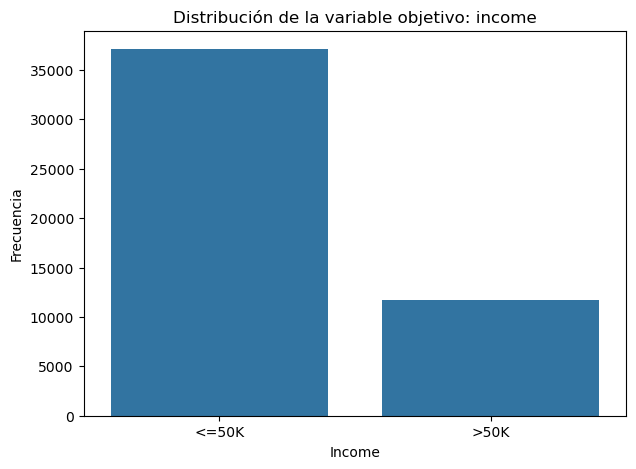

Porcentaje por clase:


income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64

In [23]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="income", order=df["income"].value_counts().index)
plt.title("Distribución de la variable objetivo: income")
plt.xlabel("Income")
plt.ylabel("Frecuencia")
plt.show()

target_pct = (df["income"].value_counts(normalize=True) * 100).round(2)
print("Porcentaje por clase:")
display(target_pct)


Veo un gran desbalanceo en la variable objetivo.
La clase <=50K es claramente mayoritaria frente a >50K.
Esto será importante en modelado y evaluación.

Análisis Univariante numérico

Resumen de skewness:


,skewness
capital-gain,11.888265
capital-loss,4.567037
fnlwgt,1.439698
age,0.556582
hours-per-week,0.239652
educational-num,-0.314229


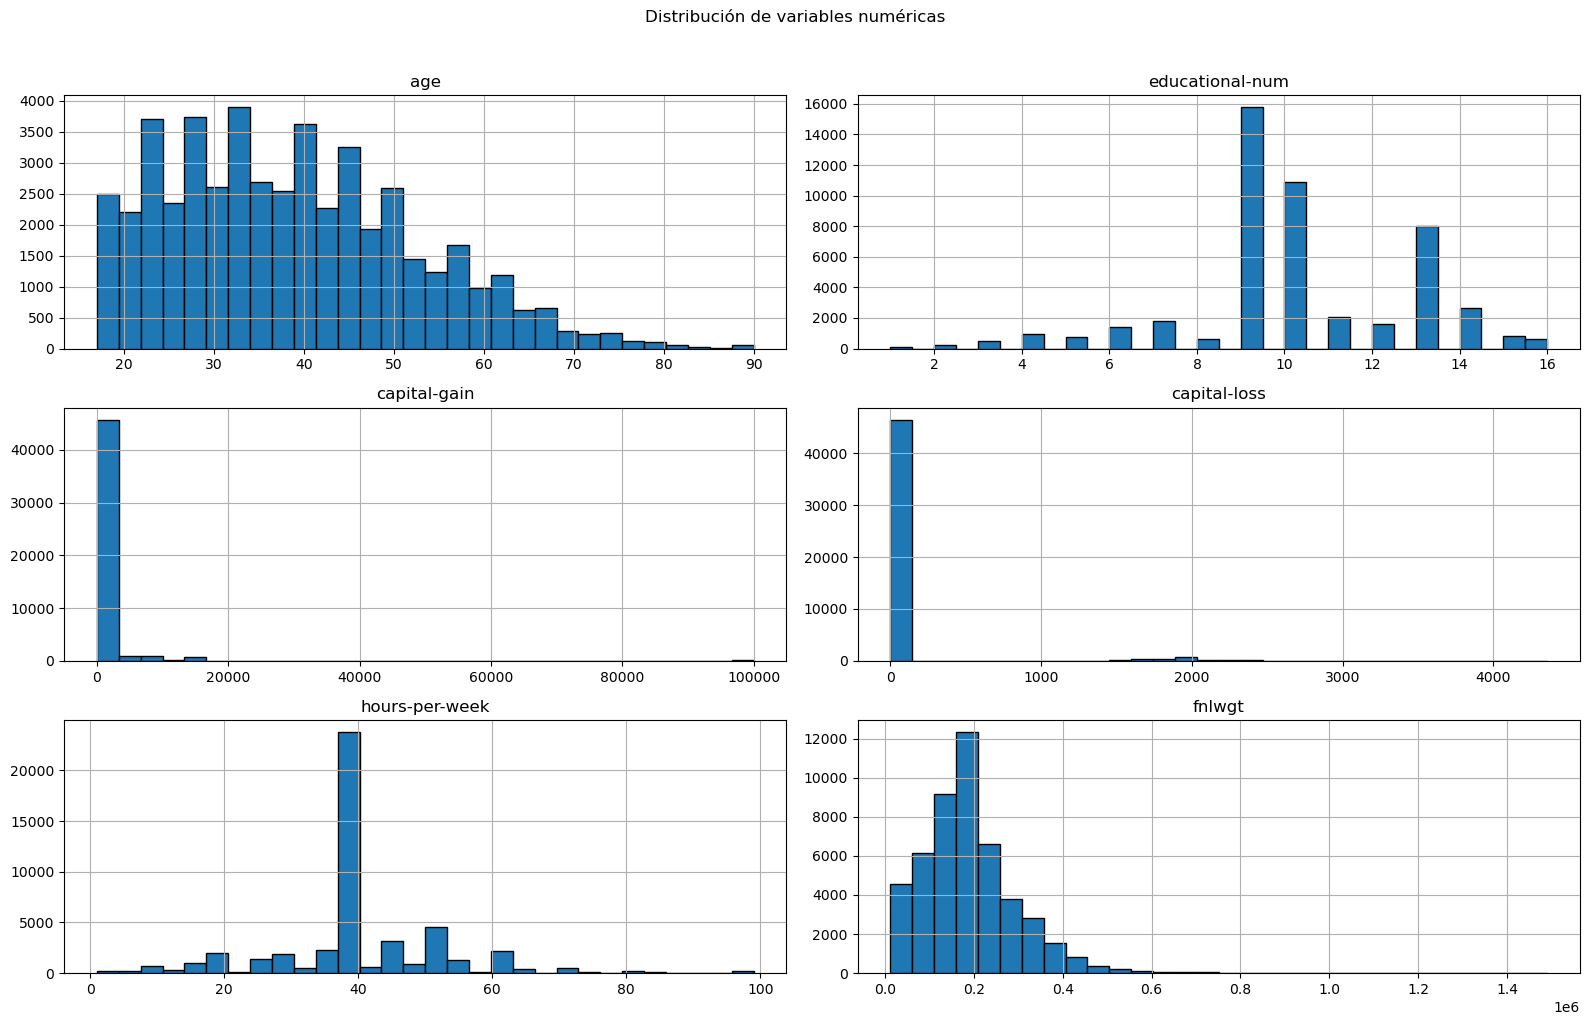

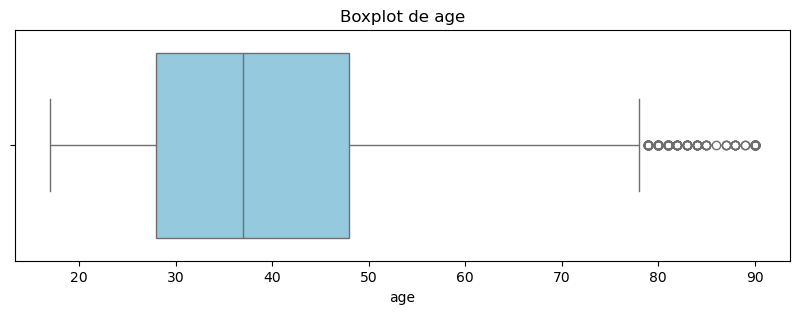

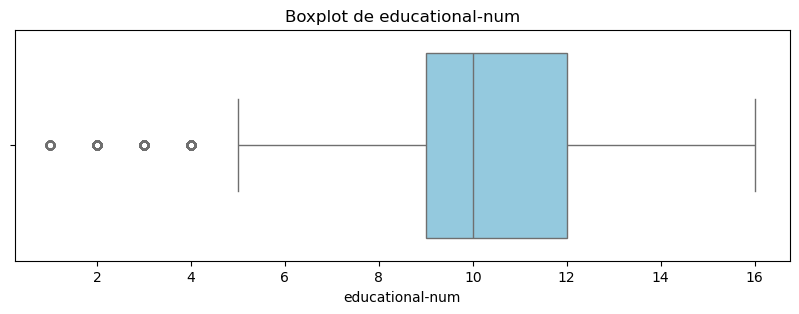

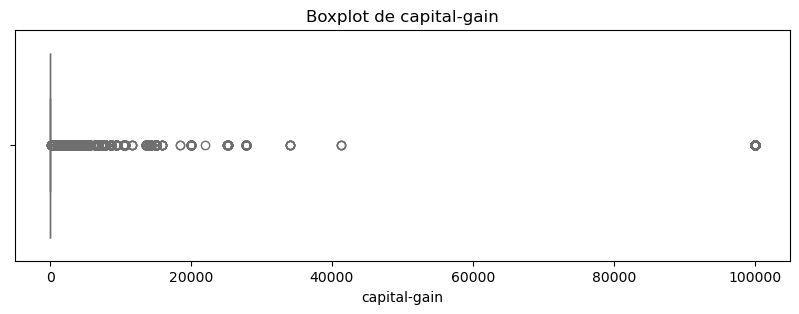

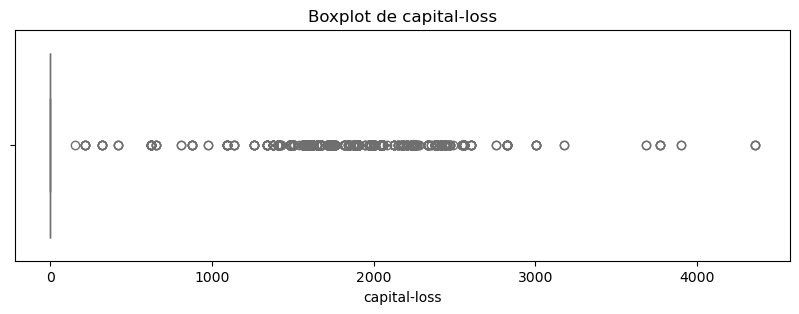

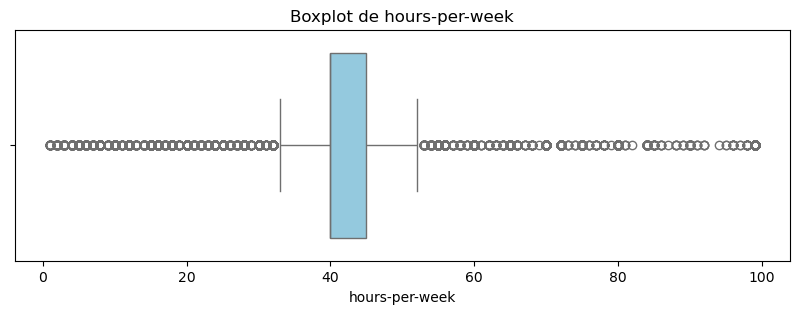

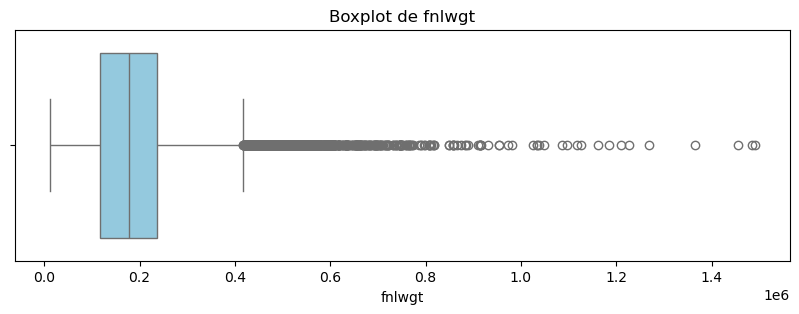

In [ ]:
print("Resumen de skewness:")
display(df[main_num_cols].skew().sort_values(ascending=False).to_frame("skewness"))


df[main_num_cols].hist(bins=30, figsize=(16, 10), edgecolor="black")
plt.suptitle("Distribución de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()


for col in main_num_cols:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot de {col}")
    plt.show()

age presenta una distribución amplia, con concentración en edades medias
hours-per-week se concentra especialmente en torno a 40 horas
capital-gain y capital-loss están fuertemente sesgadas y con gran masa en 0
fnlwgt tiene mucha dispersión pero baja interpretabilidad directa

Análisis univariante categórico


Top categorías de workclass:


workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
NaN                  2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


Top categorías de education:


education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
Name: count, dtype: int64


Top categorías de marital-status:


...

gender
Male      32614
Female    16176
Name: count, dtype: int64


Top categorías de native-country:


native-country
United-States    43792
Mexico             943
NaN                856
Philippines        294
Germany            206
Puerto-Rico        184
Canada             182
El-Salvador        155
India              151
Cuba               138
Name: count, dtype: int64


Top categorías de income:


income
<=50K    37109
>50K     11681
Name: count, dtype: int64

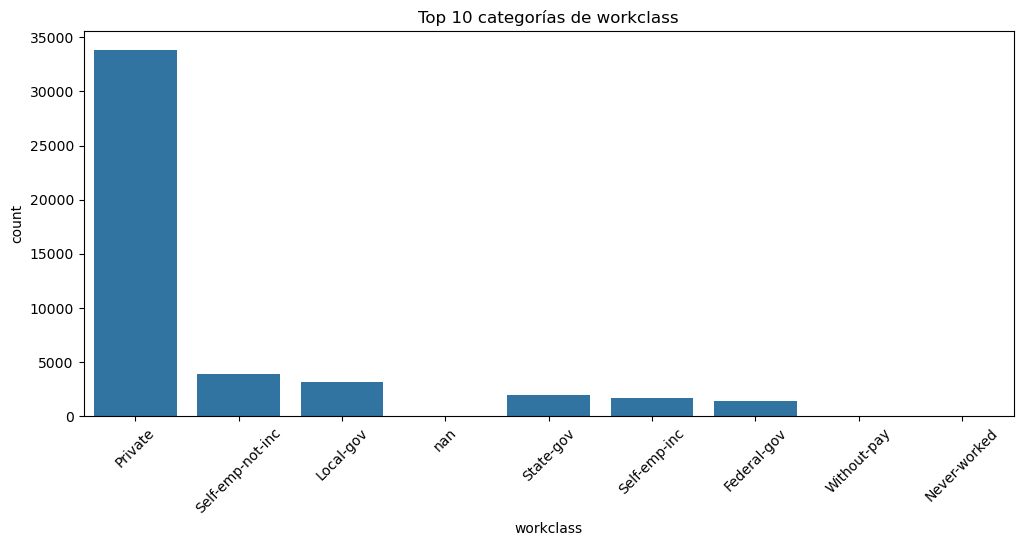

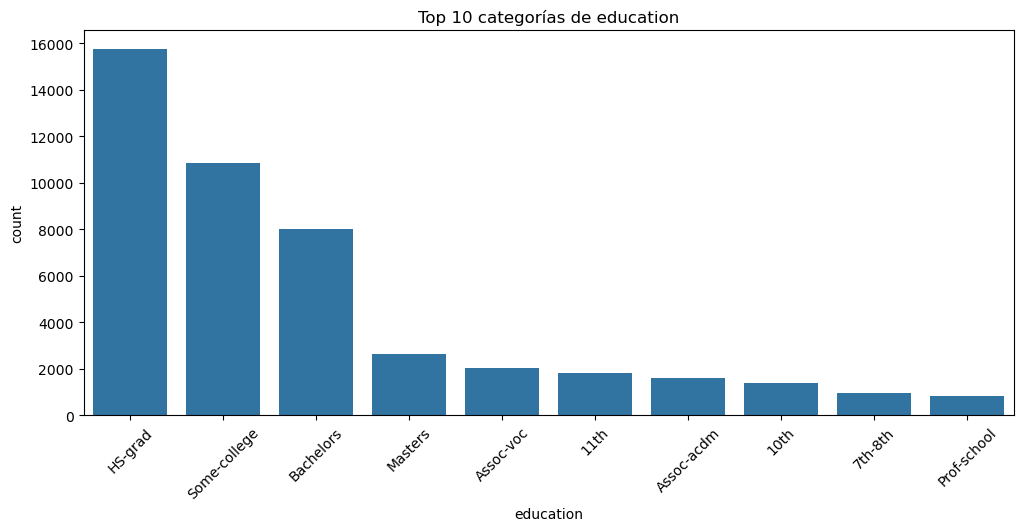

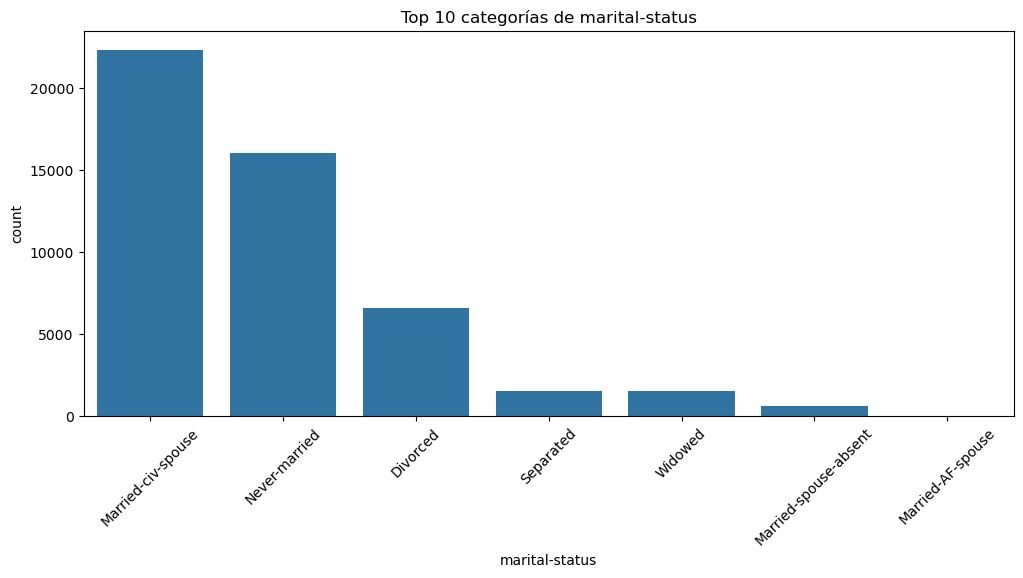

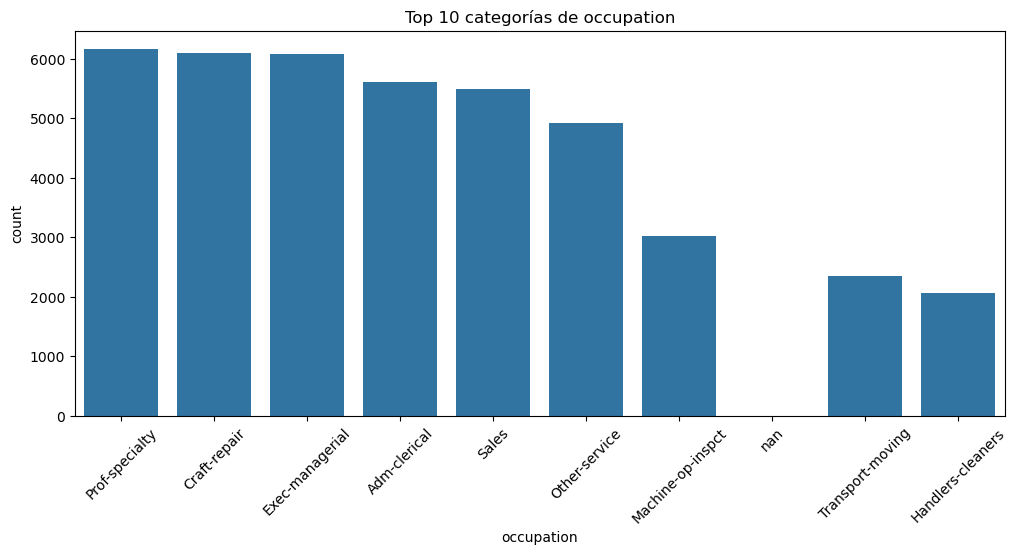

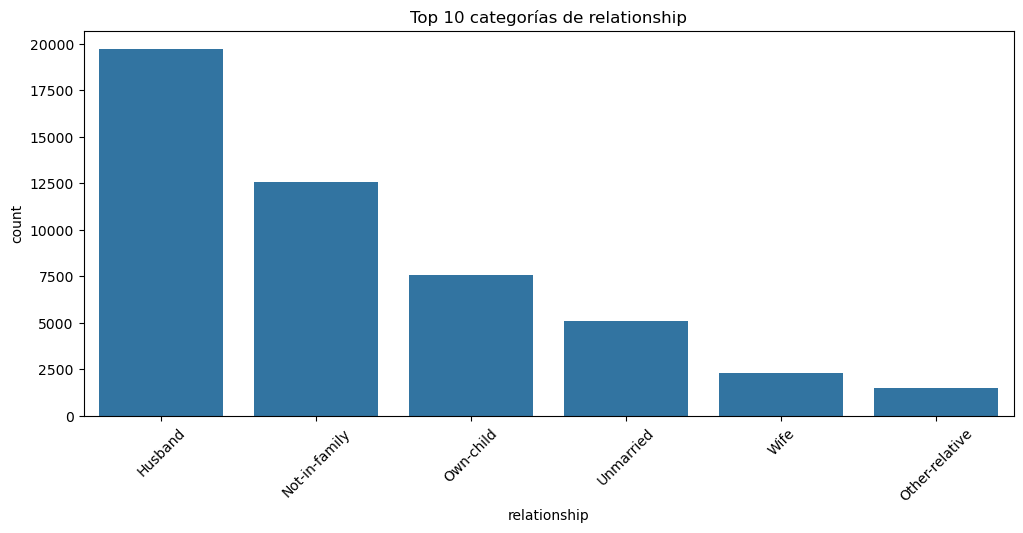

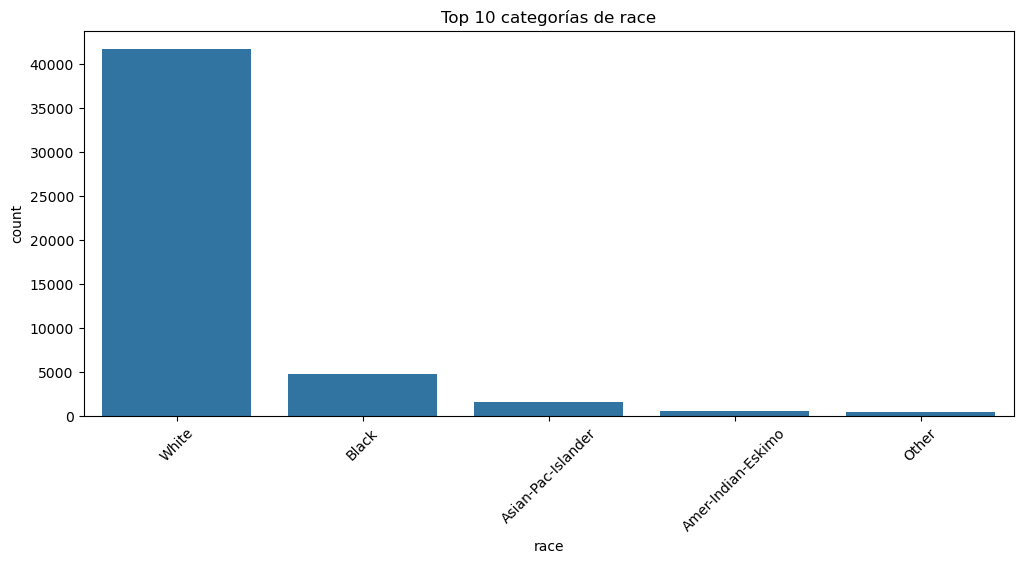

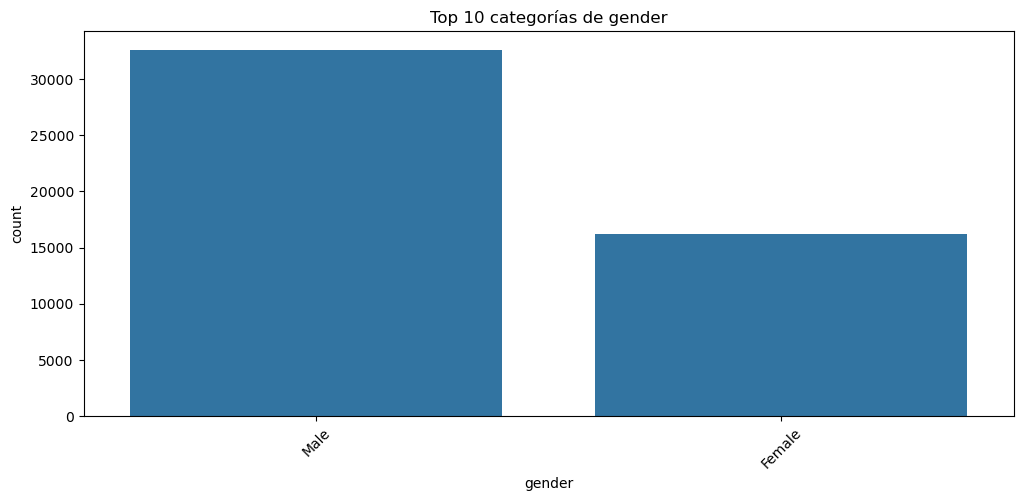

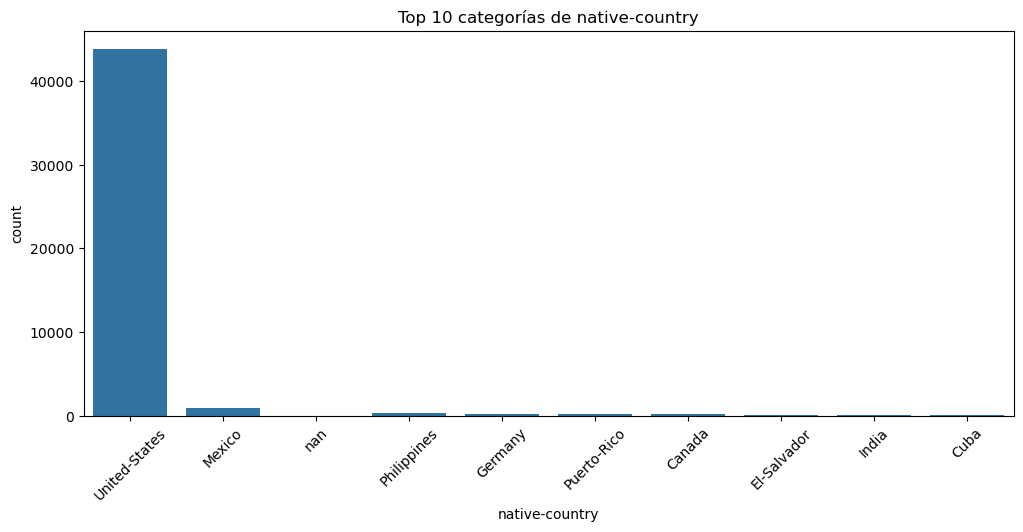

In [25]:
for col in cat_cols:
    print(f"\nTop categorías de {col}:")
    display(df[col].value_counts(dropna=False).head(10))


cat_plot_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "gender",
    "native-country"
]

for col in cat_plot_cols:
    plt.figure(figsize=(12, 5))
    order = df[col].value_counts(dropna=False).index[:10]
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Top 10 categorías de {col}")
    plt.xticks(rotation=45)
    plt.show()


En el análisis univariante categórico estudio cada variable por separado para ver sus frecuencias, porcentajes y distribución de categorías, ya que esto me ayuda a detectar patrones, desbalanceos y posibles problemas antes del modelado

Tabla de porcentaje de ceros

In [26]:
zero_features = ["capital-gain", "capital-loss"]
for col in zero_features:
    zero_pct = (df[col] == 0).mean() * 100
    print(f"{col}: {zero_pct:.2f}% de valores son 0")

capital-gain: 91.73% de valores son 0
capital-loss: 95.32% de valores son 0


La tabla de porcentaje de ceros me sirve para identificar variables con muchos valores 0, ya que eso suele indicar una distribución muy sesgada y posible necesidad de tratamiento especial

Análisis bivariante -hipótesis 1 
Education/Education-num vs income

income,<=50K,>50K
education,,
Prof-school,26.02,73.98
Doctorate,27.44,72.56
Masters,45.07,54.93
Bachelors,58.68,41.32
Assoc-acdm,74.20,25.80
Assoc-voc,74.66,25.34
Some-college,81.03,18.97
HS-grad,84.14,15.86
12th,92.67,7.33


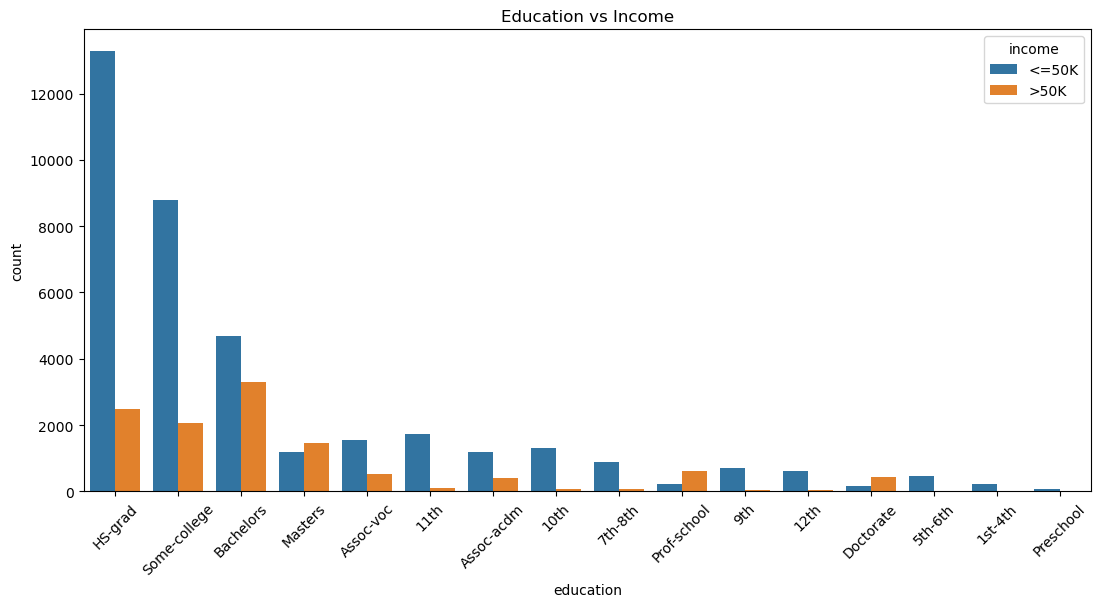

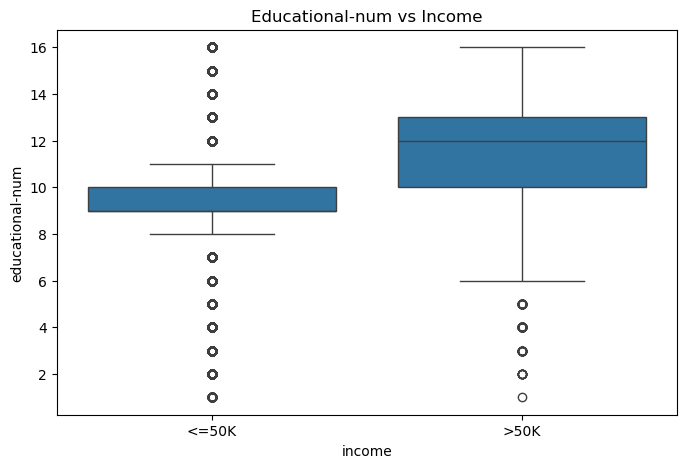

In [27]:
education_income = (
    pd.crosstab(df["education"], df["income"], normalize="index") * 100
).sort_values(by=">50K", ascending=False)

display(education_income.round(2))

plt.figure(figsize=(13, 6))
sns.countplot(data=df, x="education", hue="income",
              order=df["education"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Education vs Income")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="income", y="educational-num")
plt.title("Educational-num vs Income")
plt.show()

Analizo education y educational-num contra income para comprobar si existe relación entre nivel educativo e ingresos, ya que esta es una de las hipótesis principales del estudio

Análisis bivariante- Hipóteis 2
hours-per-week vs income

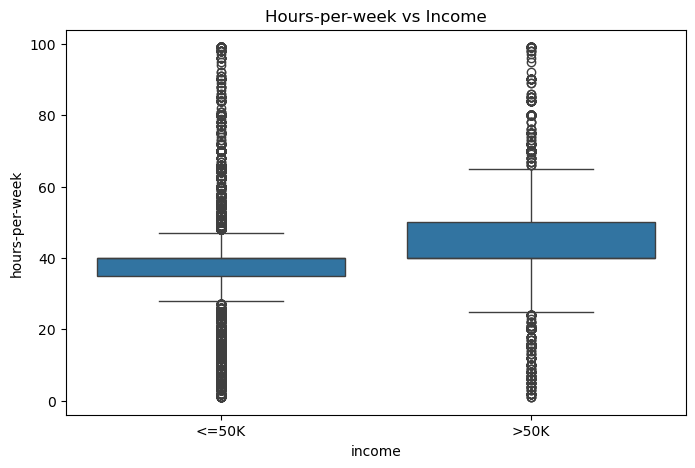

Resumen hours-per-week por income:


,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,37109.0,38.84,12.36,1.0,35.0,40.0,40.0,99.0
>50K,11681.0,45.45,11.09,1.0,40.0,40.0,50.0,99.0


In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="income", y="hours-per-week")
plt.title("Hours-per-week vs Income")
plt.show()

hours_summary = df.groupby("income")["hours-per-week"].describe().round(2)
print("Resumen hours-per-week por income:")
display(hours_summary)


He elegido estudiar hours-per-week porque pienso que puede ser una variable bastante importante para explicar el salario. Me interesa ver si al aumentar las horas trabajadas también aumenta la probabilidad de ganar más de 50K. Además, esta variable me ayuda a comprobar si hay una relación real entre esfuerzo laboral e ingresos dentro del datase

Análisis bivariante-Hipoteis 3
Ocupation vs income


Porcentaje de income por occupation:


income,<=50K,>50K
occupation,,
Exec-managerial,52.22,47.78
Prof-specialty,54.87,45.13
Armed-Forces,66.67,33.33
Protective-serv,68.64,31.36
Tech-support,70.93,29.07
Sales,73.19,26.81
Craft-repair,77.35,22.65
Transport-moving,79.58,20.42
Adm-clerical,86.30,13.70


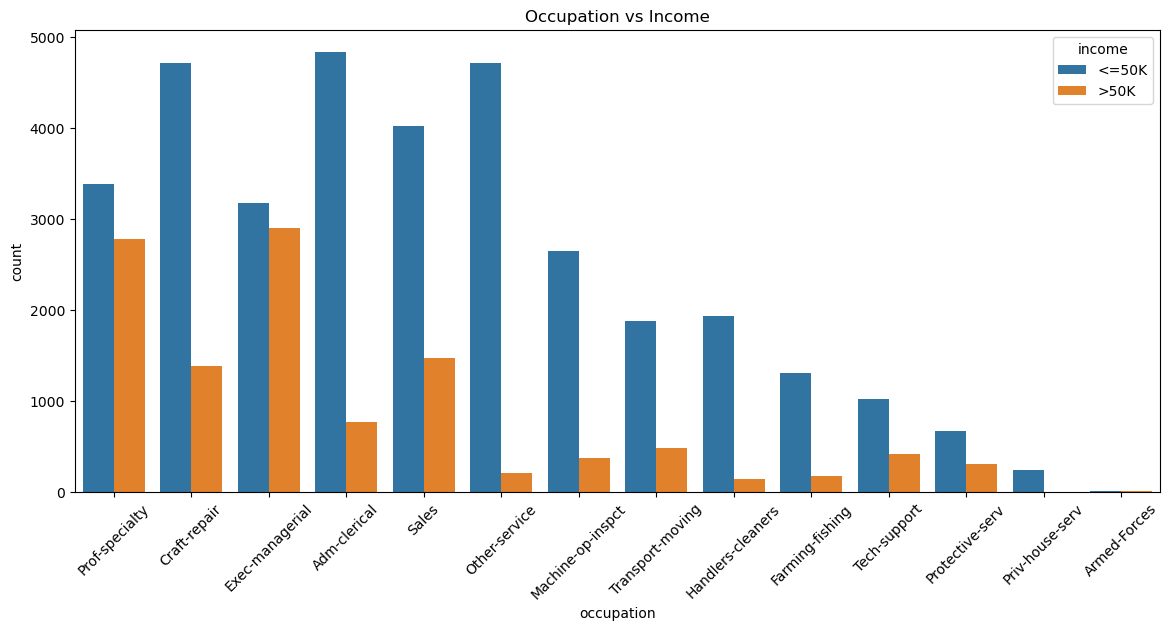

In [29]:
occupation_income = (
    pd.crosstab(df["occupation"], df["income"], normalize="index") * 100
).sort_values(by=">50K", ascending=False)

print("Porcentaje de income por occupation:")
display(occupation_income.round(2).head(15))

plt.figure(figsize=(14, 6))
order_occ = df["occupation"].value_counts().index
sns.countplot(data=df, x="occupation", hue="income", order=order_occ)
plt.xticks(rotation=45)
plt.title("Occupation vs Income")
plt.show()

Analizo occupation contra income para comprobar si la ocupación tiene relación con el nivel de ingresos, ya que es una de las variables que puede explicar mejor las diferencias salariales

Análisis bivariante-Hipótesis 4
age vs income

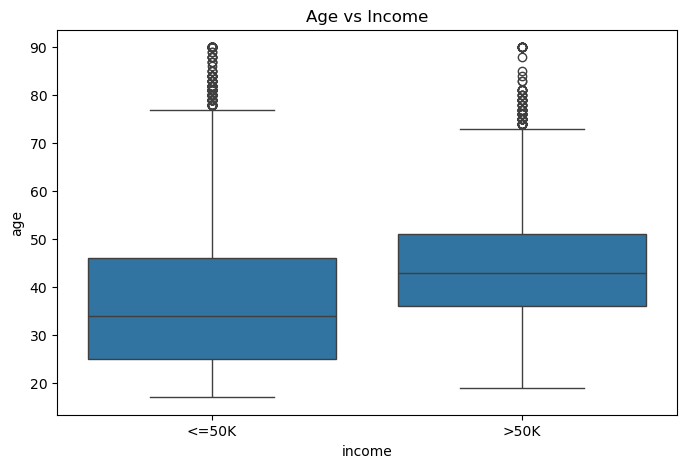

Resumen age por income:


,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,37109.0,36.88,14.10,17.0,25.0,34.0,46.0,90.0
>50K,11681.0,44.28,10.56,19.0,36.0,43.0,51.0,90.0


In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="income", y="age")
plt.title("Age vs Income")
plt.show()

age_summary = df.groupby("income")["age"].describe().round(2)
print("Resumen age por income:")
display(age_summary)

He elegido estudiar age porque pienso que puede tener bastante relación con el salario. Me interesa ver si las personas con más edad aparecen con más frecuencia en la clase >50K, o si la distribución es más equilibrada

Análisis bivariante -Hipótesis 5 
martial-status vs income

Porcentaje de income por marital-status:


income,<=50K,>50K
marital-status,,
Married-civ-spouse,55.39,44.61
Married-AF-spouse,62.16,37.84
Divorced,89.88,10.12
Married-spouse-absent,90.75,9.25
Widowed,91.57,8.43
Separated,93.53,6.47
Never-married,95.44,4.56


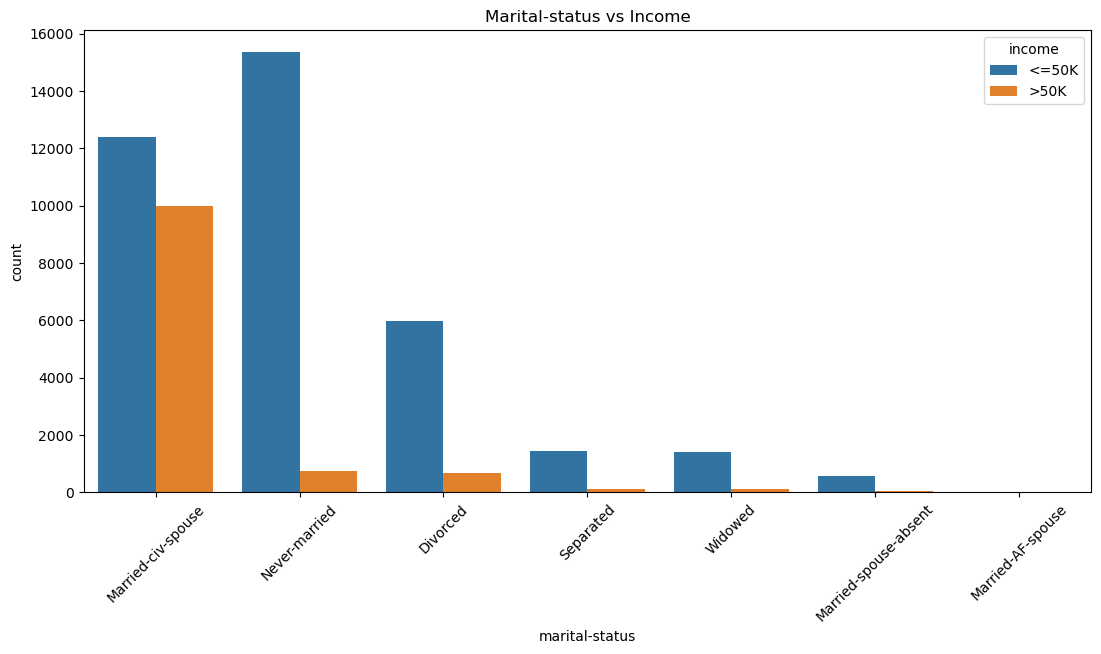

In [31]:
marital_income = (
    pd.crosstab(df["marital-status"], df["income"], normalize="index") * 100
).sort_values(by=">50K", ascending=False)

print("Porcentaje de income por marital-status:")
display(marital_income.round(2))

plt.figure(figsize=(13, 6))
sns.countplot(data=df, x="marital-status", hue="income",
              order=df["marital-status"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Marital-status vs Income")
plt.show()


Analizo marital-status contra income para comprobar si el estado civil está relacionado con el nivel de ingresos, ya que puede reflejar diferencias en el perfil personal y laboral

Otros bivariantes útiles 

Porcentaje de income por gender:


income,<=50K,>50K
gender,,
Female,89.06,10.94
Male,69.61,30.39


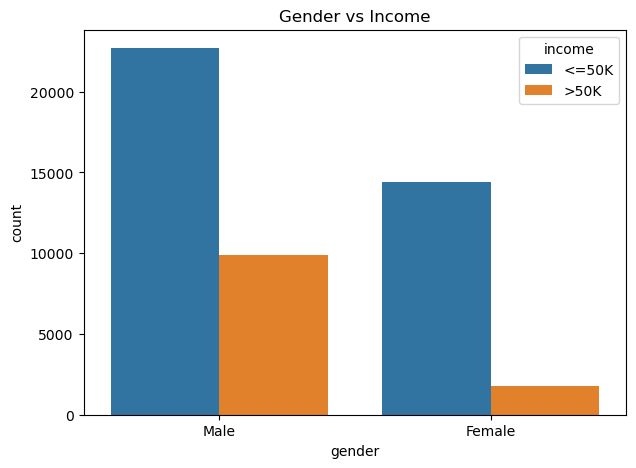

Porcentaje de income por workclass:


income,<=50K,>50K
workclass,,
Self-emp-inc,44.63,55.37
Federal-gov,60.82,39.18
Local-gov,70.44,29.56
Self-emp-not-inc,72.11,27.89
State-gov,73.25,26.75
Private,78.20,21.80
Without-pay,90.48,9.52
Never-worked,100.00,0.00


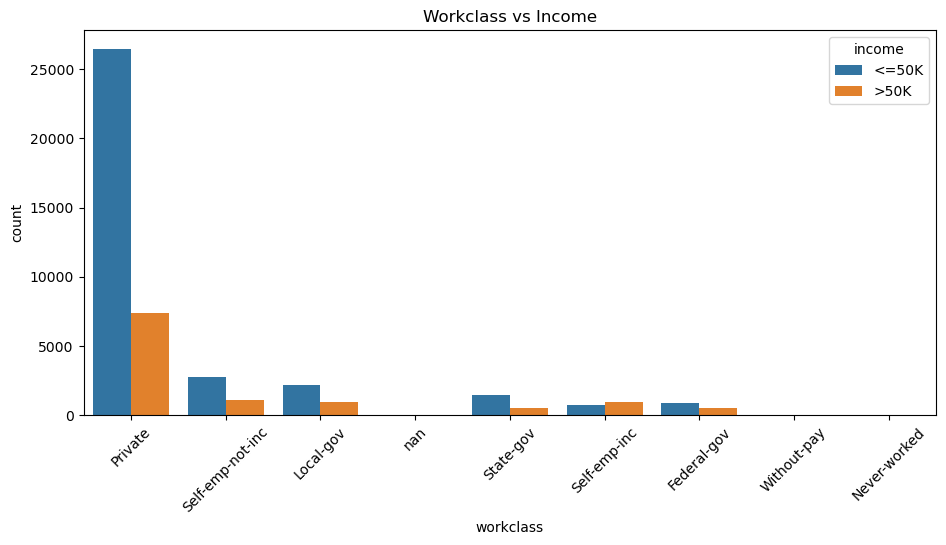

Porcentaje de income por relationship:


income,<=50K,>50K
relationship,,
Wife,53.11,46.89
Husband,55.13,44.87
Not-in-family,89.84,10.16
Unmarried,93.97,6.03
Other-relative,96.55,3.45
Own-child,98.53,1.47


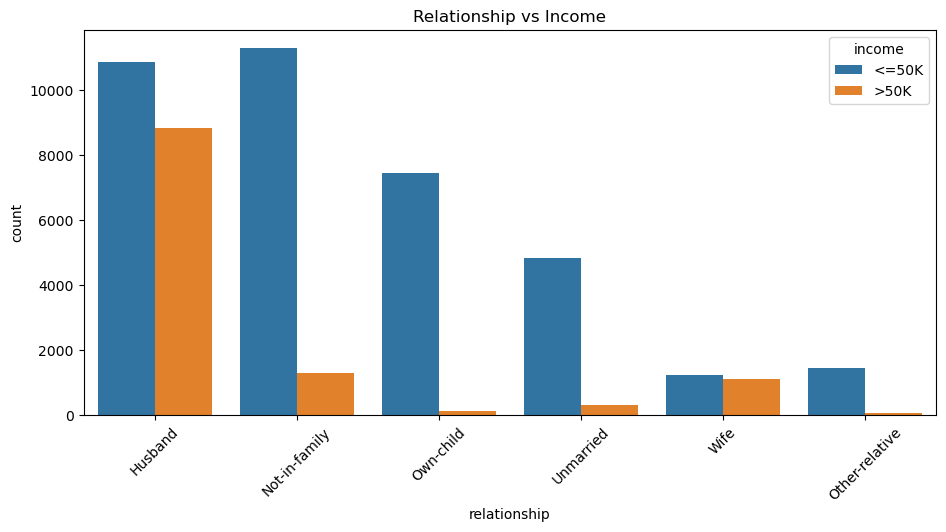

In [32]:
gender_income = (
    pd.crosstab(df["gender"], df["income"], normalize="index") * 100
)
print("Porcentaje de income por gender:")
display(gender_income.round(2))

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="gender", hue="income")
plt.title("Gender vs Income")
plt.show()


workclass_income = (
    pd.crosstab(df["workclass"], df["income"], normalize="index") * 100
).sort_values(by=">50K", ascending=False)

print("Porcentaje de income por workclass:")
display(workclass_income.round(2))

plt.figure(figsize=(11, 5))
sns.countplot(data=df, x="workclass", hue="income",
              order=df["workclass"].value_counts(dropna=False).index)
plt.xticks(rotation=45)
plt.title("Workclass vs Income")
plt.show()


relationship_income = (
    pd.crosstab(df["relationship"], df["income"], normalize="index") * 100
).sort_values(by=">50K", ascending=False)

print("Porcentaje de income por relationship:")
display(relationship_income.round(2))

plt.figure(figsize=(11, 5))
sns.countplot(data=df, x="relationship", hue="income",
              order=df["relationship"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Relationship vs Income")
plt.show()

He añadido estos bivariantes porque no quería quedarme solo con las hipótesis principales. Me parece importante mirar también otras variables que, aunque no sean las más claras , pueden mostrar patrones interesantes respecto a income. Así consigo un análisis más completo y no me dejo relaciones que puedan ser relevantes

Capital-Gain / Capital-Loss vs Income
(Aquí he tenido ayuda de la ia )

Income según existencia de capital-gain:


income,<=50K,>50K
has_capital_gain,,
0,79.47,20.53
1,38.27,61.73


Income según existencia de capital-loss:


income,<=50K,>50K
has_capital_loss,,
0,77.34,22.66
1,49.87,50.13


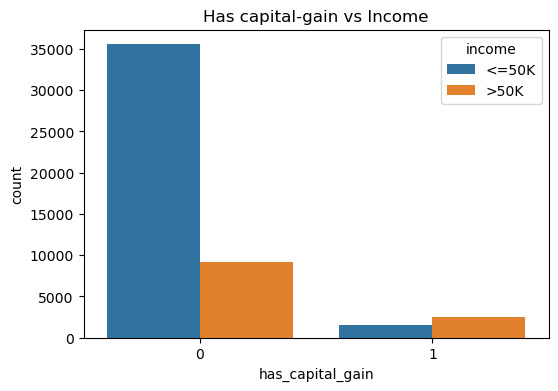

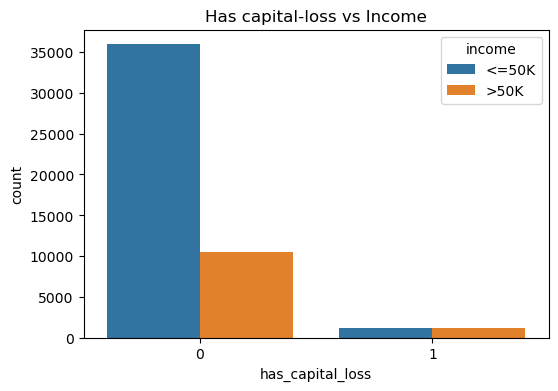

In [33]:
df["has_capital_gain"] = (df["capital-gain"] > 0).astype(int)
df["has_capital_loss"] = (df["capital-loss"] > 0).astype(int)

gain_income = pd.crosstab(df["has_capital_gain"], df["income"], normalize="index") * 100
loss_income = pd.crosstab(df["has_capital_loss"], df["income"], normalize="index") * 100

print("Income según existencia de capital-gain:")
display(gain_income.round(2))

print("Income según existencia de capital-loss:")
display(loss_income.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="has_capital_gain", hue="income")
plt.title("Has capital-gain vs Income")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="has_capital_loss", hue="income")
plt.title("Has capital-loss vs Income")
plt.show()

He incluido capital-gain y capital-loss porque, aunque casi siempre valen cero, pueden aportar bastante información cuando aparecen con valor positivo. Me interesa ver si las personas con ingresos más altos tienen más presencia de estas variables activas. Además, al transformarlas en indicadores binarios puedo comprobar de forma más clara si su existencia ya ayuda a distinguir entre <=50K y >50K

Análisis multivariante

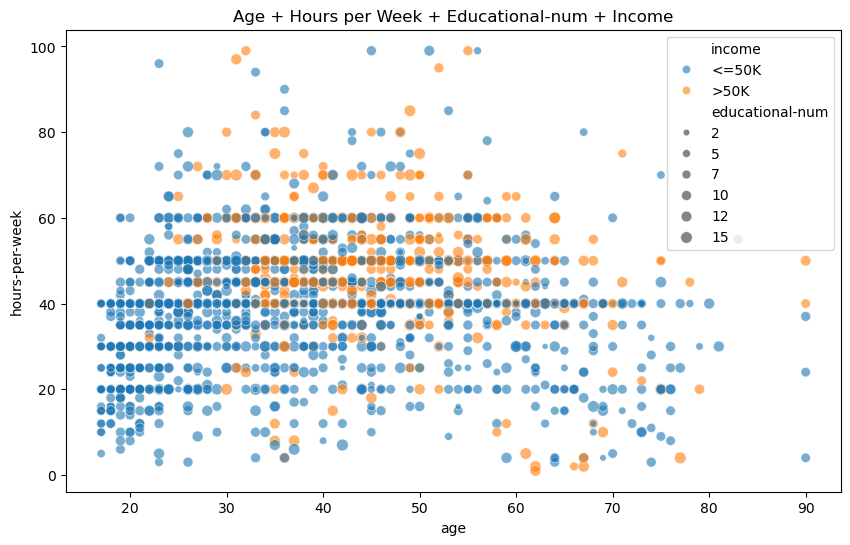

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='age',
    y='hours-per-week',
    hue='income',
    size='educational-num',
    alpha=0.6
)

plt.title('Age + Hours per Week + Educational-num + Income')

plt.show()

He incluido este análisis multivariante porque quiero entender mejor el comportamiento conjnto de las variables en cojunto. No me basta con ver cada columna por separado, ya que en este tipo de dataset las relaciones interesantes suelen aparecer cuando varias variables actúan a la vez. Así puedo comprobar mejor qué perfiles tienden a relacionarse con ingresos más altos

Matriz de correlación

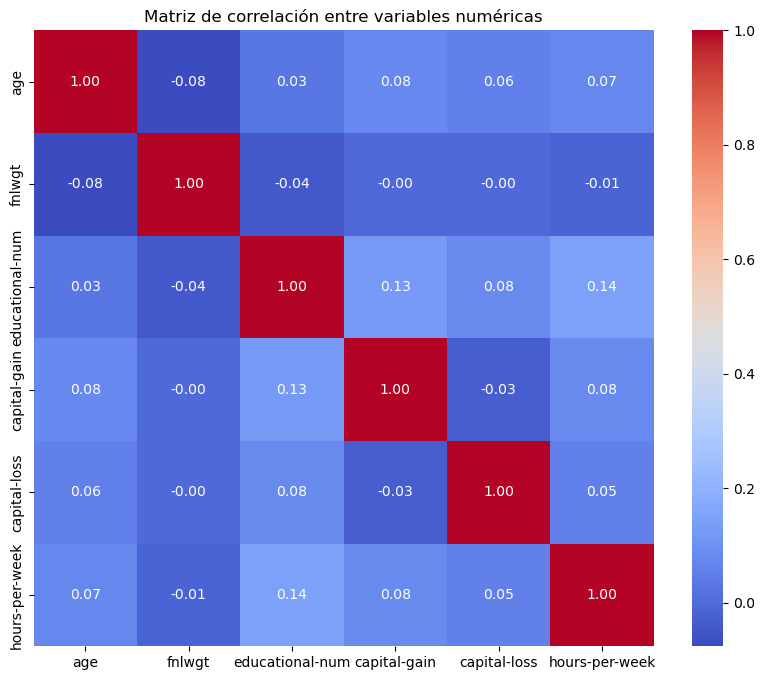

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076451,0.030635,0.077185,0.056838,0.071223
fnlwgt,-0.076451,1.000000,-0.038727,-0.003715,-0.004378,-0.013521
educational-num,0.030635,-0.038727,1.000000,0.125219,0.080986,0.143915
capital-gain,0.077185,-0.003715,0.125219,1.000000,-0.031475,0.082152
capital-loss,0.056838,-0.004378,0.080986,-0.031475,1.000000,0.054431
hours-per-week,0.071223,-0.013521,0.143915,0.082152,0.054431,1.000000


In [36]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

display(corr)

He hecho la matriz de correlación para comprobar si alguna variable numérica tiene una relación fuerte con otra. Esto me ayuda a ver qué columnas pueden aportar información parecida y cuáles pueden ser más útiles para explicar income. También me sirve para tener una visión más completa del comportamiento de las variables numéricas

Pairplot
(ayuda con ia )

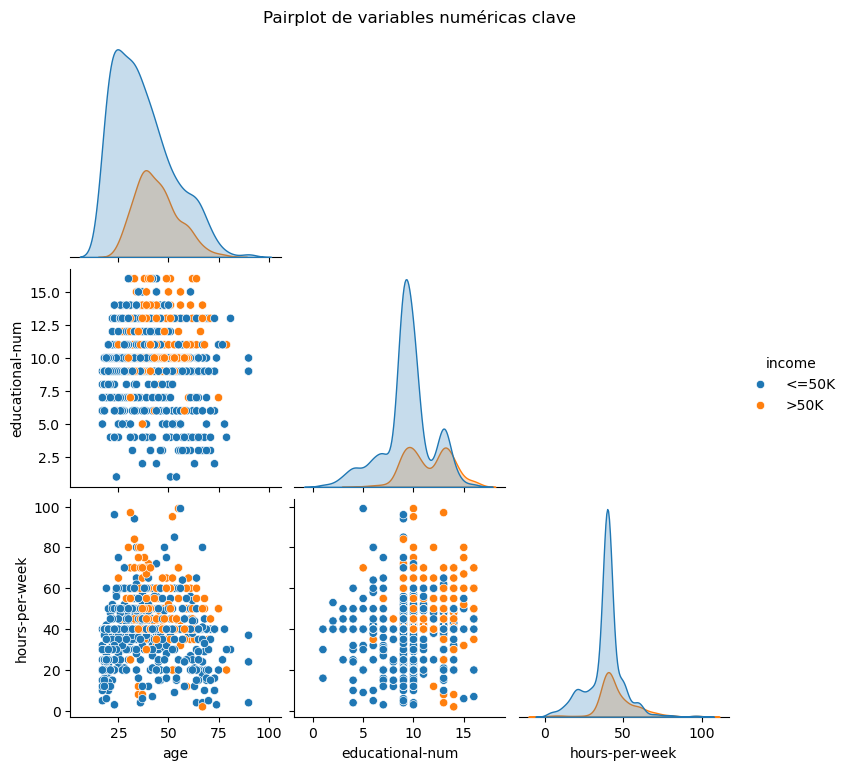

In [37]:
pairplot_cols = ["age", "educational-num", "hours-per-week"]
pairplot_sample = df[pairplot_cols + ["income"]].sample(min(1200, len(df)), random_state=42)

sns.pairplot(pairplot_sample, vars=pairplot_cols, hue="income", corner=True)
plt.suptitle("Pairplot de variables numéricas clave", y=1.02)
plt.show()

Aunque haya obtenido ayuda de la ia se porque he eligido hacer un pairplot y es porque me permite ver muchas relaciones al mismo tiempo sin tener que mirar cada variable por separado. Con este gráfico puedo comprobar si las personas con ingresos altos y bajos se comportan de manera distinta en variables como edad, nivel educativo u horas trabajadas. Me parece una forma bastante completa de resumir la relación entre las variables numéricas más importantes

Tablas cruzdas clave

In [38]:
print("Tabla cruzada gender vs income (% por fila):")
display((pd.crosstab(df["gender"], df["income"], normalize="index") * 100).round(2))

print("Tabla cruzada marital-status vs income (% por fila):")
display((pd.crosstab(df["marital-status"], df["income"], normalize="index") * 100).round(2))

print("Tabla cruzada workclass vs income (% por fila):")
display((pd.crosstab(df["workclass"], df["income"], normalize="index") * 100).round(2))

Tabla cruzada gender vs income (% por fila):


income,<=50K,>50K
gender,,
Female,89.06,10.94
Male,69.61,30.39


Tabla cruzada marital-status vs income (% por fila):


income,<=50K,>50K
marital-status,,
Divorced,89.88,10.12
Married-AF-spouse,62.16,37.84
Married-civ-spouse,55.39,44.61
Married-spouse-absent,90.75,9.25
Never-married,95.44,4.56
Separated,93.53,6.47
Widowed,91.57,8.43


Tabla cruzada workclass vs income (% por fila):


income,<=50K,>50K
workclass,,
Federal-gov,60.82,39.18
Local-gov,70.44,29.56
Never-worked,100.00,0.00
Private,78.20,21.80
Self-emp-inc,44.63,55.37
Self-emp-not-inc,72.11,27.89
State-gov,73.25,26.75
Without-pay,90.48,9.52


He usado tablas cruzadas porque creo q es más fácil entender cómo se relacionan las variables categóricas con income cuando veo los porcentajes por grupo. Así puedo comprobar rápidamente qué categorías tienen más peso dentro de cada clase y si hay diferencias claras entre perfiles. Me parece una forma muy útil de complementar los gráficos de barras qu he investigado en ejemplos de EDAs en internet

Las variables potencialmente mas relevantes son: educational-num, education, occupation, relationship, marital-status,  age, hours-per-week, capital-gain, capital-loss, workclass , gender

Variables a revisar con cuidado:
native-country: puede aportar algo, pero tiene alta cardinalidad y menor peso aparente
fnlwgt: suele tener poca interpretabilidad directa

Conclusiones:
Existe desbalanceo en la variable objetivo, con predominio de <=50K.
La educación muestra una relación clara con el salario: niveles educativos más altos tienden a concentrar más casos de >50K.
Educational-num parece una versión más limpia y útil de education para el modelado.
Las personas con mayores ingresos tienden a tener más edad, en promedio.
Hours-per-week muestra diferencias entre clases, aunque no de forma extrema.
Occupation, marital-status y relationship parecen variables categóricas con alta capacidad explicativa.
Capital-gain y capital-loss están muy sesgadas, pero la existencia de valores positivos parece discriminar bien entre clases.
Fnlwgt no parece especialmente interpretable ni claramente informativa.
Los missing values se concentran en workclass, occupation y native-country, por lo que deberán tratarse cuidadosamente en preprocessing.
Este EDA justifica un posterior bloque de selección y transformación de variables con encoding diferenciado según cardinalidad e interpretación.
